In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

DATA_DIR = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'

In [4]:
who_indicators = pd.read_csv(PROCESSED_DIR / 'who_indicators_clean.csv')
admissions = pd.read_csv(PROCESSED_DIR / 'admissions_clean.csv')
health_data = pd.read_csv(PROCESSED_DIR / 'health_data_clean.csv')

print(f"WHO Indicators: {who_indicators.shape}")
print(f"Admissions: {admissions.shape}")
print(f"Health Data: {health_data.shape}")

WHO Indicators: (140, 17)
Admissions: (164, 7)
Health Data: (474, 7)


In [5]:
df = admissions[admissions['Location'] != 'Uganda'].copy()

df = df[['Period', 'Location', 'Value']].rename(columns={
    'Period': 'year',
    'Location': 'region', 
    'Value': 'admissions'
})

df = df.sort_values(['region', 'year']).reset_index(drop=True)

print(f"Base dataset shape: {df.shape}")
print(f"Regions: {df['region'].nunique()}")
print(f"Years: {sorted(df['year'].unique())}")
df.head(10)

Base dataset shape: (157, 3)
Regions: 14
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,year,region,admissions
0,2018,Acholi,4.0
1,2019,Acholi,81.0
2,2020,Acholi,21.0
3,2020,Acholi,76.3
4,2021,Acholi,9.0
5,2021,Acholi,88.0
6,2022,Acholi,40.0
7,2022,Acholi,17.0
8,2023,Acholi,23.0
9,2023,Acholi,28.0


# Temporal Features (Lag Features)

Create time-based features crucial for outbreak prediction:

- **Lag features**: Previous period values (t-1, t-2, etc.)
- **Rolling statistics**: Moving averages, min, max
- **Change features**: Period-over-period changes

**Complexity Note**: Each lag feature adds 1 to dimensionality (d). With k lag periods across m statistics, d increases by k×m.


In [6]:
def create_lag_features(df, group_col, value_col, lags=[1, 2, 3]):
    """
    Create lag features for time series data.
    
    Complexity: O(n × |lags|) where n = number of rows
    Each lag adds 1 feature (d += |lags|)
    """
    df = df.copy()
    
    for lag in lags:
        df[f'{value_col}_lag_{lag}'] = df.groupby(group_col)[value_col].shift(lag)
        
    return df

def create_rolling_features(df, group_col, value_col, windows=[2, 3]):
    """
    Create rolling statistics features.
    
    Complexity: O(n × w) for each window size w
    Each window adds 3 features (mean, std, max) → d += 3 × |windows|
    """
    df = df.copy()
    
    for window in windows:
        rolling = df.groupby(group_col)[value_col].rolling(window=window, min_periods=1)
        
        df[f'{value_col}_roll_mean_{window}'] = rolling.mean().reset_index(level=0, drop=True)
        df[f'{value_col}_roll_std_{window}'] = rolling.std().reset_index(level=0, drop=True)
        df[f'{value_col}_roll_max_{window}'] = rolling.max().reset_index(level=0, drop=True)
    
    return df

def create_change_features(df, group_col, value_col):
    """
    Create change/difference features.
    
    Complexity: O(n)
    Adds 2 features: absolute change, percent change
    """
    df = df.copy()
    
    df[f'{value_col}_change'] = df.groupby(group_col)[value_col].diff()
    df[f'{value_col}_pct_change'] = df.groupby(group_col)[value_col].pct_change()
    
    return df

print("Creating temporal features...")
df = create_lag_features(df, 'region', 'admissions', lags=[1, 2])
df = create_rolling_features(df, 'region', 'admissions', windows=[2, 3])
df = create_change_features(df, 'region', 'admissions')

print(f"\nNew features added: {len(df.columns) - 3}")
print(f"Current shape: {df.shape}")
df.head()

Creating temporal features...

New features added: 10
Current shape: (157, 13)


,year,region,admissions,admissions_lag_1,admissions_lag_2,admissions_roll_mean_2,admissions_roll_std_2,admissions_roll_max_2,admissions_roll_mean_3,admissions_roll_std_3,admissions_roll_max_3,admissions_change,admissions_pct_change
0,2018,Acholi,4.0,NaN,NaN,4.00,NaN,4.0,4.000000,NaN,4.0,NaN,NaN
1,2019,Acholi,81.0,4.0,NaN,42.50,54.447222,81.0,42.500000,54.447222,81.0,77.0,19.250000
2,2020,Acholi,21.0,81.0,4.0,51.00,42.426407,81.0,35.333333,40.451617,81.0,-60.0,-0.740741
3,2020,Acholi,76.3,21.0,81.0,48.65,39.103005,76.3,59.433333,33.367100,81.0,55.3,2.633333
4,2021,Acholi,9.0,76.3,21.0,42.65,47.588286,76.3,35.433333,35.896564,76.3,-67.3,-0.882045


# Spatial Features

Encode regional information for the model:

- **Label encoding**: Simple integer encoding for regions
- **Regional statistics**: Cross-regional comparisons
- **National context**: Comparison to national averages

**Complexity Note**: One-hot encoding would add r-1 features (r = regions). We use label encoding + derived features to manage dimensionality.


In [7]:
label_encoder = LabelEncoder()
df['region_encoded'] = label_encoder.fit_transform(df['region'])

region_stats = df.groupby('region')['admissions'].agg(['mean', 'std', 'min', 'max']).reset_index()
region_stats.columns = ['region', 'region_mean', 'region_std', 'region_min', 'region_max']
df = df.merge(region_stats, on='region', how='left')

year_stats = df.groupby('year')['admissions'].agg(['mean', 'std']).reset_index()
year_stats.columns = ['year', 'national_mean', 'national_std']
df = df.merge(year_stats, on='year', how='left')

df['relative_to_national'] = df['admissions'] / df['national_mean']
df['deviation_from_national'] = df['admissions'] - df['national_mean']

print(f"Spatial features added")
print(f"Current shape: {df.shape}")
print(f"\nRegion encoding mapping:")
for region, code in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"  {code}: {region}")

Spatial features added
Current shape: (157, 22)

Region encoding mapping:
  0: Acholi
  1: Ankole
  2: Buganda
  3: Bugisu
  4: Bukedi
  5: Bunyoro
  6: Busoga
  7: Kampala
  8: Karamoja
  9: Kigezi
  10: Lango
  11: Teso
  12: Tooro
  13: West Nile


# Target Variable Engineering

The outbreak classification target:

- **Binary classification**: Outbreak (1) vs Normal (0)
- **Threshold**: Using 75th percentile as outbreak indicator



Outbreak threshold (75th percentile): 65.00

Target distribution:
outbreak
0    117
1     40
Name: count, dtype: int64

Class balance: 25.5% outbreak cases


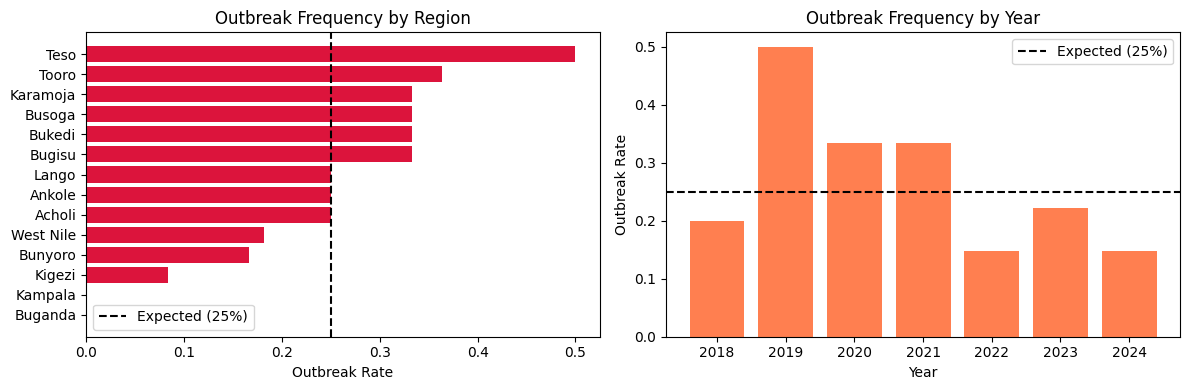

In [17]:
outbreak_threshold = df['admissions'].quantile(0.75)
print(f"Outbreak threshold (75th percentile): {outbreak_threshold:.2f}")

df['outbreak'] = (df['admissions'] >= outbreak_threshold).astype(int)

print(f"\nTarget distribution:")
print(df['outbreak'].value_counts())
print(f"\nClass balance: {df['outbreak'].mean()*100:.1f}% outbreak cases")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

outbreak_by_region = df.groupby('region')['outbreak'].mean().sort_values()
axes[0].barh(outbreak_by_region.index, outbreak_by_region.values, color='crimson')
axes[0].axvline(0.25, color='black', linestyle='--', label='Expected (25%)')
axes[0].set_xlabel('Outbreak Rate')
axes[0].set_title('Outbreak Frequency by Region')
axes[0].legend()

outbreak_by_year = df.groupby('year')['outbreak'].mean()
axes[1].bar(outbreak_by_year.index.astype(str), outbreak_by_year.values, color='coral')
axes[1].axhline(0.25, color='black', linestyle='--', label='Expected (25%)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Outbreak Rate')
axes[1].set_title('Outbreak Frequency by Year')
axes[1].legend()

plt.tight_layout()
plt.show()

# Feature Summary & Complexity Analysis

In [20]:
feature_categories = {
    'Temporal (Lag)': [c for c in df.columns if 'lag' in c],
    'Temporal (Rolling)': [c for c in df.columns if 'roll' in c],
    'Temporal (Change)': [c for c in df.columns if 'change' in c.lower()],
    'Spatial': ['region_encoded', 'region_mean', 'region_std', 'region_min', 'region_max'],
    'National Context': ['national_mean', 'national_std', 'relative_to_national', 'deviation_from_national'],
    'Target': ['outbreak'],
    'Identifiers': ['year', 'region', 'admissions']
}

print("\nFeature Categories:")
total_features = 0
for category, features in feature_categories.items():
    existing = [f for f in features if f in df.columns]
    print(f"  {category}: {len(existing)} features")
    if existing and category not in ['Target', 'Identifiers']:
        total_features += len(existing)

print(f"\n  TOTAL PREDICTOR FEATURES (d): {total_features}")

print("\n" + "="*70)
print("COMPLEXITY IMPLICATIONS")
print("="*70)
n = len(df.dropna()) 
d = total_features

print(f"""
Dataset dimensions:
  - Samples (n): {n} (after removing NaN from lags)
  - Features (d): {d}

Random Forest complexity (k=100 trees, h=10 depth):
  - Training: O(n × k × d × log(n)) = O({n} × 100 × {d} × {np.log2(n):.1f}) ≈ O({n * 100 * d * np.log2(n) / 1e6:.2f}M)
  - Inference per sample: O(k × h) = O(100 × 10) = O(1000)

LightGBM complexity (k=100 trees, b=255 bins):
  - Training: O(n × d × k) = O({n} × {d} × 100) ≈ O({n * d * 100 / 1e6:.2f}M)
  - Inference per sample: O(k × h) = O(1000)
""")


Feature Categories:
  Temporal (Lag): 2 features
  Temporal (Rolling): 6 features
  Temporal (Change): 2 features
  Spatial: 5 features
  National Context: 4 features
  Target: 1 features
  Identifiers: 3 features

  TOTAL PREDICTOR FEATURES (d): 19

COMPLEXITY IMPLICATIONS

Dataset dimensions:
  - Samples (n): 129 (after removing NaN from lags)
  - Features (d): 19

Random Forest complexity (k=100 trees, h=10 depth):
  - Training: O(n × k × d × log(n)) = O(129 × 100 × 19 × 7.0) ≈ O(1.72M)
  - Inference per sample: O(k × h) = O(100 × 10) = O(1000)

LightGBM complexity (k=100 trees, b=255 bins):
  - Training: O(n × d × k) = O(129 × 19 × 100) ≈ O(0.25M)
  - Inference per sample: O(k × h) = O(1000)



# Handle Missing Values & Prepare Final Dataset

In [21]:
print("Missing values before cleanup:")
missing = df.isnull().sum()
print(missing[missing > 0])

df_clean = df.dropna().copy()

print(f"\nOriginal shape: {df.shape}")
print(f"After removing NaN: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")

FEATURE_COLS = [c for c in df_clean.columns if c not in ['year', 'region', 'admissions', 'outbreak']]
TARGET_COL = 'outbreak'

print(f"\nFeature columns ({len(FEATURE_COLS)}):")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i}. {col}")

Missing values before cleanup:
admissions_lag_1         14
admissions_lag_2         28
admissions_roll_std_2    14
admissions_roll_std_3    14
admissions_change        14
admissions_pct_change    14
dtype: int64

Original shape: (157, 23)
After removing NaN: (129, 23)
Rows removed: 28

Feature columns (19):
  1. admissions_lag_1
  2. admissions_lag_2
  3. admissions_roll_mean_2
  4. admissions_roll_std_2
  5. admissions_roll_max_2
  6. admissions_roll_mean_3
  7. admissions_roll_std_3
  8. admissions_roll_max_3
  9. admissions_change
  10. admissions_pct_change
  11. region_encoded
  12. region_mean
  13. region_std
  14. region_min
  15. region_max
  16. national_mean
  17. national_std
  18. relative_to_national
  19. deviation_from_national


# Feature Correlation Analysis

Examine feature correlations to identify potential redundancy (impacts effective dimensionality).


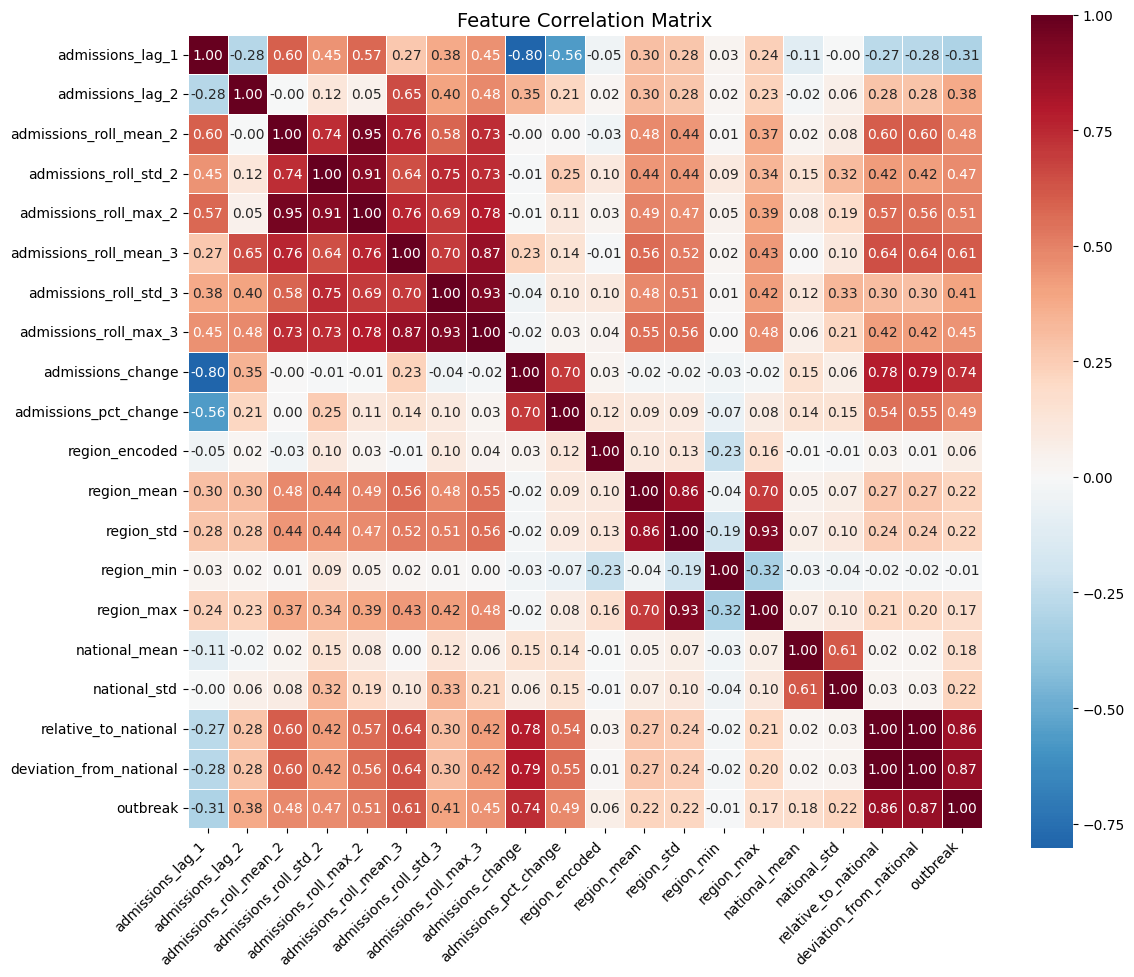


Highly correlated feature pairs (|r| > 0.8):
  admissions_lag_1 <-> admissions_change: -0.804
  admissions_roll_mean_2 <-> admissions_roll_max_2: 0.955
  admissions_roll_std_2 <-> admissions_roll_max_2: 0.906
  admissions_roll_mean_3 <-> admissions_roll_max_3: 0.870
  admissions_roll_std_3 <-> admissions_roll_max_3: 0.934
  region_mean <-> region_std: 0.855
  region_std <-> region_max: 0.927
  relative_to_national <-> deviation_from_national: 0.995
  relative_to_national <-> outbreak: 0.858
  deviation_from_national <-> outbreak: 0.867

Feature correlations with target (outbreak):
deviation_from_national    0.867190
relative_to_national       0.857906
admissions_change          0.739218
admissions_roll_mean_3     0.611734
admissions_roll_max_2      0.509052
admissions_pct_change      0.485197
admissions_roll_mean_2     0.480668
admissions_roll_std_2      0.468855
admissions_roll_max_3      0.446458
admissions_roll_std_3      0.406955
admissions_lag_2           0.377061
admissions_lag_

In [25]:
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df_clean[FEATURE_COLS + [TARGET_COL]].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nHighly correlated feature pairs (|r| > 0.8):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            print(f"  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i,j]:.3f}")

print("\nFeature correlations with target (outbreak):")
target_corr = corr_matrix[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
print(target_corr.to_string())

In [26]:
df_clean.to_csv(PROCESSED_DIR / 'malaria_features_engineered.csv', index=False)

import json
feature_info = {
    'feature_columns': FEATURE_COLS,
    'target_column': TARGET_COL,
    'n_features': len(FEATURE_COLS),
    'n_samples': len(df_clean),
    'outbreak_threshold': float(outbreak_threshold)
}

with open(PROCESSED_DIR / 'feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)
